In [1]:
#imports
import os, json, math, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer, AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments, Trainer,
    TrainerCallback, EarlyStoppingCallback,
    set_seed,
)
from datasets import Dataset

warnings.filterwarnings('ignore')
set_seed(42)
print('Imports OK')

Imports OK


In [2]:
BASE_ROOT = Path('/content/drive/MyDrive/Rajdeep_Document')

PATHS = dict(
    # ── DAPTTAPT reads from task corpus (labeled train set, used as unlabeled) ──
    task_csv     = BASE_ROOT / 'data'    / 'climate_train.csv',

    # ── DAPTTAPT starts from DAPT model, NOT base MiniLM ──────────────────────
    dapt_model   = BASE_ROOT / 'models'  / 'final' / 'dapt_minilm_climate',

    # ── Outputs ────────────────────────────────────────────────────────────
    model_dir    = BASE_ROOT / 'models'  / 'final' / 'dapttapt_minilm_climate',
    lr_sweep_dir = BASE_ROOT / 'models'  / 'dapttapt_lr_sweep',
    log_dir      = BASE_ROOT / 'logs'    / 'dapttapt',
    log_csv      = BASE_ROOT / 'logs'    / 'dapttapt' / 'dapttapt_training_logs.csv',
    results_dir  = BASE_ROOT / 'results' / 'dapttapt',
    eval_json    = BASE_ROOT / 'results' / 'dapttapt' / 'dapttapt_evaluation_results.json',
    report_txt   = BASE_ROOT / 'results' / 'dapttapt' / 'dapttapt_comparison_report.txt',
    plots_dir    = BASE_ROOT / 'plots'   / 'dapttapt',
)

for p in [PATHS['model_dir'], PATHS['lr_sweep_dir'], PATHS['log_dir'],
          PATHS['results_dir'], PATHS['plots_dir']]:
    Path(p).mkdir(parents=True, exist_ok=True)

PATHS = {k: str(v) for k, v in PATHS.items()}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

 Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


In [5]:
# ── LR sweep: narrower range than DAPT because we're further specialising ──
# DAPTTAPT fine-tunes an already domain-adapted model, so large LRs risk
# catastrophic forgetting of what DAPT taught.
TAPT_LR_SWEEP = [5e-6, 1e-5, 3e-5]

CFG = dict(
    # DAPTTAPT starts from DAPT model, not from microsoft/MiniLM
    # dapt_model       = PATHS['dapt_model'], # Removed duplicate definition

    text_column      = 'text_clean',      # column name in climate_train.csv
    seq_len          = 128,               # no curriculum needed at task scale;
                                          # 128 covers most task sentences well
    mlm_probability  = 0.15,             # standard MLM mask rate

    # ── Key DAPTTAPT hyperparameter (from the paper): 25 epochs ───────────────
    # Corpus is tiny so we need many passes. Dynamic masking (different random
    # masks per epoch) prevents the model from simply memorising positions.
    tapt_epochs      = 25,

    # ── LR sweep: short run to pick best LR before the full 100-epoch run ──
    sweep_epochs     = 10,
    sweep_batch      = 16,               # fixed; corpus too small for BS grid

    # ── Full DAPTTAPT run (best LR from sweep) ─────────────────────────────────
    full_batch       = 16,
    warmup_ratio     = 0.06,             # matches paper's 6% warmup
    weight_decay     = 0.01,
    val_split        = 0.10,
    early_stop_patience = 5,            # stop if eval_loss stalls for 8 epochs

    seed             = 42,
    **PATHS,
)

print('DAPTTAPT Config ready.')
print(f'   Starting model   : DAPT checkpoint (not base MiniLM)')
print(f'   LR sweep values  : {TAPT_LR_SWEEP}')
print(f'   Sweep epochs     : {CFG["sweep_epochs"]}')
print(f'   Full DAPTTAPT epochs : {CFG["tapt_epochs"]}')
print(f'   Seq length       : {CFG["seq_len"]} tokens')
print(f'   Dynamic masking  : ON (mask_prob={CFG["mlm_probability"]})')
print(f'   Early stopping   : patience={CFG["early_stop_patience"]}')

DAPTTAPT Config ready.
   Starting model   : DAPT checkpoint (not base MiniLM)
   LR sweep values  : [5e-06, 1e-05, 3e-05]
   Sweep epochs     : 10
   Full DAPTTAPT epochs : 25
   Seq length       : 128 tokens
   Dynamic masking  : ON (mask_prob=0.15)
   Early stopping   : patience=5


In [6]:
# ── DAPTTAPT corpus = labeled task training set used WITHOUT its labels ─────────
# The model only sees text_clean; labels are ignored entirely during DAPTTAPT.
# This is the key difference from DAPT: far smaller but maximally task-relevant.

df = pd.read_csv(PATHS['task_csv'])
print(f'Task corpus shape   : {df.shape}')
print(f'Columns available   : {list(df.columns)}')
print(f'Nulls in text_clean : {df["text_clean"].isnull().sum()}')

# Keep only the text column; everything else is irrelevant for MLM
df = df[['text_clean']].dropna()
df['text_clean'] = df['text_clean'].astype(str).str.strip()
df = df[df['text_clean'].str.len() > 20].reset_index(drop=True)

# Word count summary
df['_wc'] = df['text_clean'].str.split().str.len()
print(f'\nTask corpus rows     : {len(df):,}')
print(f'Total words          : {df["_wc"].sum():,}')
print(f'Avg words / sample   : {df["_wc"].mean():.1f}')
print(f'Max words / sample   : {df["_wc"].max()}')
df.drop(columns=['_wc'], inplace=True)

print('\n⚠️  Note: This is the DAPTTAPT corpus — same text the model will')
print('    be fine-tuned on downstream. Tight distribution alignment')
print('    is the point; small size is expected and intentional.')

Task corpus shape   : (15611, 6)
Columns available   : ['text_clean', 'source_file', 'folder', 'lang', 'word_count', 'climate_score']
Nulls in text_clean : 0

Task corpus rows     : 15,598
Total words          : 591,577
Avg words / sample   : 37.9
Max words / sample   : 512

⚠️  Note: This is the DAPTTAPT corpus — same text the model will
    be fine-tuned on downstream. Tight distribution alignment
    is the point; small size is expected and intentional.


In [7]:
# ── Load tokenizer from DAPT model (guarantees vocab consistency) ────────────
tokenizer = AutoTokenizer.from_pretrained(PATHS['dapt_model'])

TEXT_COL = CFG['text_column']

def tokenize_fn(examples):
    return tokenizer(
        examples[TEXT_COL],
        truncation=True,
        max_length=CFG['seq_len'],
        padding=False,
        return_special_tokens_mask=True,
    )

hf_ds      = Dataset.from_pandas(df)
tokenized  = hf_ds.map(tokenize_fn, batched=True,
                        remove_columns=[TEXT_COL], desc='Tokenising')
split      = tokenized.train_test_split(test_size=CFG['val_split'],
                                        seed=CFG['seed'])
train_ds   = split['train']
eval_ds    = split['test']

# ── Dynamic masking collator ─────────────────────────────────────────────────
# This generates a DIFFERENT random mask every epoch.
# Critical for TAPT: with only ~N samples × 100 epochs, dynamic masking
# means the model sees N × 100 distinct masked variants — preventing
# pure memorisation of mask positions.
collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=CFG['mlm_probability'],
)

print(f'Tokenisation complete')
print(f'   Train samples : {len(train_ds):,}  (seq_len={CFG["seq_len"]})')
print(f'   Eval  samples : {len(eval_ds):,}')
print(f'   Dynamic masking: ON — each epoch sees a fresh random mask')

Tokenising:   0%|          | 0/15598 [00:00<?, ? examples/s]

Tokenisation complete
   Train samples : 14,038  (seq_len=128)
   Eval  samples : 1,560
   Dynamic masking: ON — each epoch sees a fresh random mask


In [8]:
# ── Reuse the same compute_perplexity function from DAPT notebook ────────────
def compute_perplexity(model, dataset, collator, batch_size=64, desc='Eval'):
    loader = DataLoader(
        dataset, batch_size=batch_size,
        collate_fn=collator, pin_memory=torch.cuda.is_available()
    )
    total_loss, n = 0.0, 0
    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            total_loss += model(**batch).loss.item()
            n += 1
    avg = total_loss / n
    return {'loss': round(avg, 4), 'perplexity': round(math.exp(avg), 4)}

# ── Baseline = DAPT model on the TASK eval set ───────────────────────────────
# This is the DAPT → DAPTTAPT starting point.
# We measure how well the domain-adapted model already fits the task corpus
# BEFORE task-adaptive pretraining.
print('📏 Computing DAPT model perplexity on task corpus (DAPTTAPT baseline)...')
dapt_model = AutoModelForMaskedLM.from_pretrained(
    PATHS['dapt_model'], attn_implementation='eager'
).to(DEVICE)
dapt_model.eval()

DAPT_METRICS = compute_perplexity(
    dapt_model, eval_ds, collator, batch_size=64, desc='DAPT Baseline'
)
print(f'\n   DAPT model — Loss      : {DAPT_METRICS["loss"]}')
print(f'   DAPT model — Perplexity: {DAPT_METRICS["perplexity"]}')
print(f'\n   (This is the starting point; DAPTTAPT should reduce this further.)')

del dapt_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print('🧹 DAPT model freed.')

📏 Computing DAPT model perplexity on task corpus (DAPTTAPT baseline)...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DAPT Baseline:   0%|          | 0/25 [00:00<?, ?it/s]


   DAPT model — Loss      : 3.0844
   DAPT model — Perplexity: 21.854

   (This is the starting point; DAPTTAPT should reduce this further.)
🧹 DAPT model freed.


In [9]:
class DetailedLoggerCallback(TrainerCallback):
    def __init__(self):
        self.records      = []
        self._step_losses = []
        self._epoch_start = None

    def on_epoch_begin(self, args, state, control, **kwargs):
        self._epoch_start = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self._step_losses.append(logs['loss'])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        eval_loss  = metrics.get('eval_loss', float('nan'))
        ppl        = math.exp(eval_loss) if not math.isnan(eval_loss) else float('nan')
        train_loss = (sum(self._step_losses) / len(self._step_losses)
                      if self._step_losses else float('nan'))
        lr         = (state.log_history[-1].get('learning_rate', float('nan'))
                      if state.log_history else float('nan'))
        rec = dict(
            epoch         = int(round(state.epoch)),
            train_loss    = round(train_loss, 6),
            eval_loss     = round(eval_loss,  6),
            perplexity    = round(ppl,        4),
            learning_rate = lr,
            epoch_time_s  = round(time.time() - self._epoch_start, 2)
                            if self._epoch_start else None,
        )
        self.records.append(rec)
        self._step_losses = []
        print(f"  Ep {rec['epoch']:>3} | "
              f"Train {rec['train_loss']:.4f} | "
              f"Eval {rec['eval_loss']:.4f} | "
              f"PPL {rec['perplexity']:.3f} | "
              f"LR {rec['learning_rate']:.2e}")

print('✅ Callback ready.')

✅ Callback ready.


In [11]:
# ── Why sweep and not grid? ───────────────────────────────────────────────────
# The corpus is tiny; batch size variance is negligible at this scale.
# LR is the only hyperparameter that meaningfully changes outcome.
# We pick the best LR here, then use it for the full 100-epoch run.

SWEEP_RESULTS   = {}
BEST_LR         = None
BEST_LR_PPL     = float('inf')

print(f'LR Sweep: {len(TAPT_LR_SWEEP)} values × {CFG["sweep_epochs"]} epochs\n')

for lr in TAPT_LR_SWEEP:
    lr_key = f'lr={lr:.0e}'
    print(f'\n{"="*55}')
    print(f'  LR Sweep — {lr_key}')
    print(f'{"="*55}')

    # Always start from DAPT checkpoint, not base MiniLM
    model  = AutoModelForMaskedLM.from_pretrained(
        PATHS['dapt_model'], attn_implementation='eager'
    )
    logger = DetailedLoggerCallback()

    steps_per_epoch = math.ceil(len(train_ds) / CFG['sweep_batch'])
    total_steps     = steps_per_epoch * CFG['sweep_epochs']
    warmup_steps    = max(1, int(total_steps * CFG['warmup_ratio']))
    sweep_out_dir   = f"{PATHS['lr_sweep_dir']}/{lr_key}"

    args = TrainingArguments(
        output_dir                  = sweep_out_dir,
        num_train_epochs            = CFG['sweep_epochs'],
        per_device_train_batch_size = CFG['sweep_batch'],
        per_device_eval_batch_size  = 64,
        learning_rate               = lr,
        weight_decay                = CFG['weight_decay'],
        warmup_steps                = warmup_steps,
        lr_scheduler_type           = 'cosine',
        fp16                        = False,
        eval_strategy               = 'epoch',
        save_strategy               = 'no',
        logging_steps               = max(5, steps_per_epoch // 4),
        report_to                   = 'none',
        seed                        = CFG['seed'],
        dataloader_num_workers      = 2,
        push_to_hub                 = False,
    )

    trainer = Trainer(
        model         = model,
        args          = args,
        train_dataset = train_ds,
        eval_dataset  = eval_ds,
        # tokenizer     = tokenizer, # Removed: Trainer does not accept tokenizer directly
        data_collator = collator,
        callbacks     = [logger],
    )

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    log_df    = pd.DataFrame(logger.records)
    final_ppl = log_df['perplexity'].iloc[-1]
    best_ppl  = log_df['perplexity'].min()

    SWEEP_RESULTS[lr_key] = {
        'lr'              : lr,
        'log_df'          : log_df,
        'final_perplexity': final_ppl,
        'best_perplexity' : best_ppl,
        'time_min'        : round(elapsed / 60, 2),
    }

    if final_ppl < BEST_LR_PPL:
        BEST_LR_PPL = final_ppl
        BEST_LR     = lr
        print(f'  New best LR: {lr:.0e}  PPL={final_ppl:.4f}')

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    print(f'  Done {elapsed/60:.1f} min | Final PPL={final_ppl:.4f}')

print(f'\n{"="*55}')
print(f'  LR Sweep Complete')
print(f'  Best LR  : {BEST_LR:.0e}')
print(f'  Best PPL : {BEST_LR_PPL:.4f}')
print(f'{"="*55}')

LR Sweep: 3 values × 10 epochs


  LR Sweep — lr=5e-06


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,3.335242,3.110190
2,3.260297,3.092366
3,3.278294,3.140895
4,3.275696,3.117094
5,3.281224,3.036601
6,3.255167,3.112381
7,3.226456,3.081172
8,3.268251,3.034483
9,3.234182,3.089508
10,3.294218,3.108925


  Ep   1 | Train 3.3012 | Eval 3.1102 | PPL 22.425 | LR nan
  Ep   2 | Train 3.3034 | Eval 3.0924 | PPL 22.029 | LR nan
  Ep   3 | Train 3.2927 | Eval 3.1409 | PPL 23.125 | LR nan
  Ep   4 | Train 3.2805 | Eval 3.1171 | PPL 22.581 | LR nan
  Ep   5 | Train 3.2866 | Eval 3.0366 | PPL 20.834 | LR nan
  Ep   6 | Train 3.2570 | Eval 3.1124 | PPL 22.474 | LR nan
  Ep   7 | Train 3.2541 | Eval 3.0812 | PPL 21.784 | LR nan
  Ep   8 | Train 3.2617 | Eval 3.0345 | PPL 20.790 | LR nan
  Ep   9 | Train 3.2582 | Eval 3.0895 | PPL 21.966 | LR nan
  Ep  10 | Train 3.2680 | Eval 3.1089 | PPL 22.397 | LR nan
  New best LR: 5e-06  PPL=22.3970
  Done 24.5 min | Final PPL=22.3970

  LR Sweep — lr=1e-05


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,3.342411,3.116910
2,3.261682,3.098269
3,3.273245,3.143121
4,3.264624,3.114672
5,3.264568,3.031140
6,3.231488,3.104030
7,3.199880,3.070522
8,3.237468,3.020347
9,3.202837,3.076811
10,3.260841,3.094276


  Ep   1 | Train 3.3048 | Eval 3.1169 | PPL 22.576 | LR nan
  Ep   2 | Train 3.3049 | Eval 3.0983 | PPL 22.160 | LR nan
  Ep   3 | Train 3.2884 | Eval 3.1431 | PPL 23.176 | LR nan
  Ep   4 | Train 3.2697 | Eval 3.1147 | PPL 22.526 | LR nan
  Ep   5 | Train 3.2701 | Eval 3.0311 | PPL 20.721 | LR nan
  Ep   6 | Train 3.2357 | Eval 3.1040 | PPL 22.288 | LR nan
  Ep   7 | Train 3.2289 | Eval 3.0705 | PPL 21.553 | LR nan
  Ep   8 | Train 3.2321 | Eval 3.0203 | PPL 20.498 | LR nan
  Ep   9 | Train 3.2271 | Eval 3.0768 | PPL 21.689 | LR nan
  Ep  10 | Train 3.2358 | Eval 3.0943 | PPL 22.071 | LR nan
  New best LR: 1e-05  PPL=22.0713
  Done 24.5 min | Final PPL=22.0713

  LR Sweep — lr=3e-05


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,3.391752,3.156279
2,3.294597,3.134506
3,3.288967,3.172708
4,3.256886,3.125166
5,3.239967,3.031968
6,3.185478,3.094707
7,3.135474,3.052726
8,3.159521,2.988901
9,3.121567,3.047974
10,3.174579,3.063019


  Ep   1 | Train 3.3306 | Eval 3.1563 | PPL 23.483 | LR nan
  Ep   2 | Train 3.3374 | Eval 3.1345 | PPL 22.977 | LR nan
  Ep   3 | Train 3.3061 | Eval 3.1727 | PPL 23.872 | LR nan
  Ep   4 | Train 3.2662 | Eval 3.1252 | PPL 22.764 | LR nan
  Ep   5 | Train 3.2466 | Eval 3.0320 | PPL 20.738 | LR nan
  Ep   6 | Train 3.1942 | Eval 3.0947 | PPL 22.081 | LR nan
  Ep   7 | Train 3.1711 | Eval 3.0527 | PPL 21.173 | LR nan
  Ep   8 | Train 3.1593 | Eval 2.9889 | PPL 19.864 | LR nan
  Ep   9 | Train 3.1464 | Eval 3.0480 | PPL 21.073 | LR nan
  Ep  10 | Train 3.1521 | Eval 3.0630 | PPL 21.392 | LR nan
  New best LR: 3e-05  PPL=21.3920
  Done 24.6 min | Final PPL=21.3920

  LR Sweep Complete
  Best LR  : 3e-05
  Best PPL : 21.3920


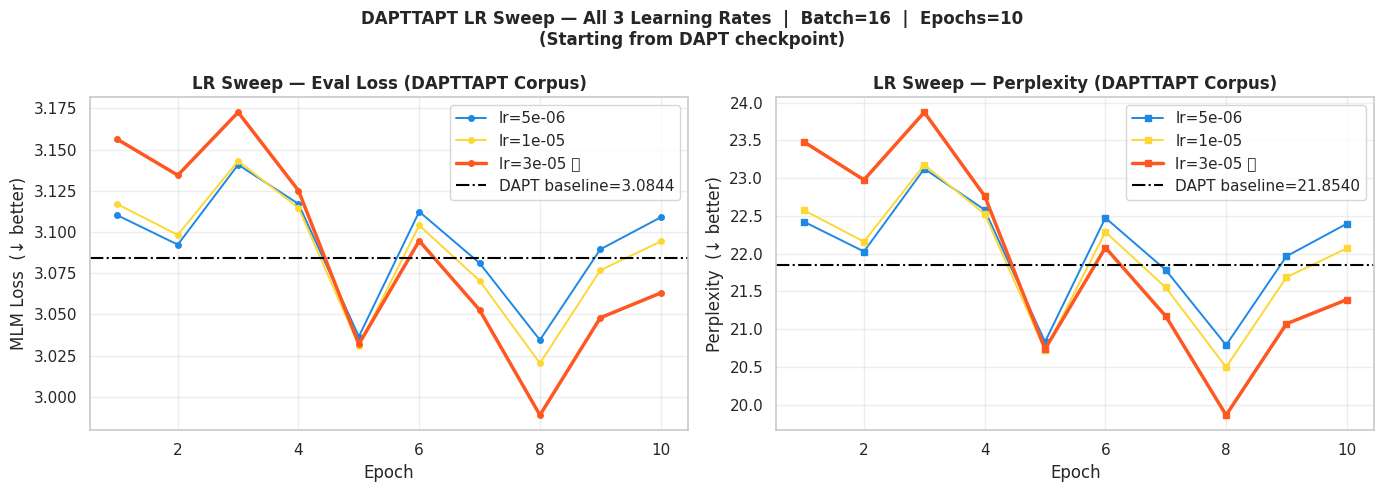

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapttapt/dapttapt_lr_sweep.png


In [13]:
sns.set_theme(style='whitegrid', font_scale=1.0)
LR_COLORS = {5e-6: '#1E88E5', 1e-5: '#FDD835', 2e-5: '#E53935', 3e-5: '#FF5722'} # Added 3e-5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax = axes[0]
for lr_key, res in SWEEP_RESULTS.items():
    ldf = res['log_df']
    lr  = res['lr']
    lw  = 2.5 if lr == BEST_LR else 1.4
    ax.plot(ldf['epoch'], ldf['eval_loss'], lw=lw, color=LR_COLORS[lr],
            marker='o', ms=4,
            label=f'{lr_key}' + (' ⭐' if lr == BEST_LR else ''))
ax.axhline(DAPT_METRICS['loss'], color='black', ls='-.', lw=1.5,
           label=f'DAPT baseline={DAPT_METRICS["loss"]:.4f}')
ax.set_title('LR Sweep — Eval Loss (DAPTTAPT Corpus)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MLM Loss  (↓ better)')
ax.legend(); ax.grid(alpha=0.35)

# Perplexity curves
ax = axes[1]
for lr_key, res in SWEEP_RESULTS.items():
    ldf = res['log_df']
    lr  = res['lr']
    lw  = 2.5 if lr == BEST_LR else 1.4
    ax.plot(ldf['epoch'], ldf['perplexity'], lw=lw, color=LR_COLORS[lr],
            marker='s', ms=4,
            label=f'{lr_key}' + (' ⭐' if lr == BEST_LR else ''))
ax.axhline(DAPT_METRICS['perplexity'], color='black', ls='-.', lw=1.5,
           label=f'DAPT baseline={DAPT_METRICS["perplexity"]:.4f}')
ax.set_title('LR Sweep — Perplexity (DAPTTAPT Corpus)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity  (↓ better)')
ax.legend(); ax.grid(alpha=0.35)

plt.suptitle(
    f'DAPTTAPT LR Sweep — All 3 Learning Rates  |  Batch={CFG["sweep_batch"]}  |  '
    f'Epochs={CFG["sweep_epochs"]}\n(Starting from DAPT checkpoint)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapttapt_lr_sweep.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

In [16]:
# ════════════════════════════════════════════════════════════════════
#  FULL DAPTTAPT RUN
#  100 epochs, dynamic masking, best LR from sweep, early stopping
#  Starts from DAPT checkpoint — this is the DAPT + DAPTTAPT pipeline
# ════════════════════════════════════════════════════════════════════

print(f'🚀 Full DAPTTAPT Run')
print(f'   Starting from : DAPT checkpoint ({PATHS["dapt_model"]})')
print(f'   Best LR       : {BEST_LR:.0e}')
print(f'   Epochs        : {CFG["tapt_epochs"]}  (with dynamic masking)')
print(f'   Early stop    : patience={CFG["early_stop_patience"]} epochs')
print(f'   Batch size    : {CFG["full_batch"]}')

dapttapt_model = AutoModelForMaskedLM.from_pretrained(
    PATHS['dapt_model'], attn_implementation='eager'
)

logger_tapt   = DetailedLoggerCallback()

steps_per_epoch = math.ceil(len(train_ds) / CFG['full_batch'])
total_steps     = steps_per_epoch * CFG['tapt_epochs']
warmup_steps    = max(1, int(total_steps * CFG['warmup_ratio']))

args_tapt = TrainingArguments(
    output_dir                  = PATHS['model_dir'],
    num_train_epochs            = CFG['tapt_epochs'],
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 64,
    learning_rate               = BEST_LR,
    weight_decay                = CFG['weight_decay'],
    warmup_steps                = warmup_steps,
    lr_scheduler_type           = 'cosine',
    fp16                        = False,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,
    save_total_limit            = 1,
    logging_steps               = max(5, steps_per_epoch // 4),
    report_to                   = 'none',
    seed                        = CFG['seed'],
    dataloader_num_workers      = 2,
    push_to_hub                 = False,
)

trainer_tapt = Trainer(
    model         = dapttapt_model,
    args          = args_tapt,
    train_dataset = train_ds,
    eval_dataset  = eval_ds,
    # tokenizer     = tokenizer, # Removed: Trainer does not accept tokenizer directly
    data_collator = collator,
    callbacks     = [
        logger_tapt,
        # Early stopping: prevents overfitting on the small task corpus
        EarlyStoppingCallback(early_stopping_patience=CFG['early_stop_patience']),
    ],
)

print(f'\n{"="*60}')
t_tapt = time.time()
trainer_tapt.train()
tapt_time = time.time() - t_tapt
print(f'{"="*60}')

log_df_tapt = pd.DataFrame(logger_tapt.records)

# Save model + tokenizer + logs
trainer_tapt.save_model(PATHS['model_dir'])
tokenizer.save_pretrained(PATHS['model_dir'])
log_df_tapt.to_csv(PATHS['log_csv'], index=False)

actual_epochs = log_df_tapt['epoch'].max()
print(f'\n✅ Full DAPTTAPT done in {tapt_time/60:.1f} min')
print(f'   Epochs run (incl. early stop) : {actual_epochs}')
print(f'   Best eval loss                 : {log_df_tapt["eval_loss"].min():.6f}')
print(f'   Best perplexity                : {log_df_tapt["perplexity"].min():.4f}')
print(f'   Model saved → {PATHS["model_dir"]}')

🚀 Full DAPTTAPT Run
   Starting from : DAPT checkpoint (/content/drive/MyDrive/Rajdeep_Document/models/final/dapt_minilm_climate)
   Best LR       : 3e-05
   Epochs        : 25  (with dynamic masking)
   Early stop    : patience=5 epochs
   Batch size    : 16


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,3.409564,3.180829
2,3.341277,3.164973
3,3.330939,3.209611
4,3.258226,3.171994
5,3.216235,3.097718
6,3.240812,3.127752
7,3.201177,3.104549
8,3.162641,3.022940
9,3.113837,3.060250
10,3.097769,3.044719


  Ep   1 | Train 3.3542 | Eval 3.1808 | PPL 24.067 | LR nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Ep  20 | Train 2.8875 | Eval 2.9054 | PPL 18.272 | LR nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Full DAPTTAPT done in 54.0 min
   Epochs run (incl. early stop) : 20
   Best eval loss                 : 2.888007
   Best perplexity                : 17.9575
   Model saved → /content/drive/MyDrive/Rajdeep_Document/models/final/dapttapt_minilm_climate


In [17]:
print('📏 Computing AFTER-DAPTTAPT metrics...')
final_model = AutoModelForMaskedLM.from_pretrained(
    PATHS['model_dir'], attn_implementation='eager'
).to(DEVICE)

TAPT_METRICS = compute_perplexity(
    final_model, eval_ds, collator, batch_size=64, desc='Post-DAPTTAPT'
)

loss_delta = TAPT_METRICS['loss']       - DAPT_METRICS['loss']
ppl_delta  = TAPT_METRICS['perplexity'] - DAPT_METRICS['perplexity']
loss_pct   = loss_delta / DAPT_METRICS['loss']       * 100
ppl_pct    = ppl_delta  / DAPT_METRICS['perplexity'] * 100

print(f'\n{"Stage":<20} {"Loss":>10}  {"Perplexity":>12}')
print('-' * 45)
print(f'{"DAPT (start)":<20} {DAPT_METRICS["loss"]:>10.4f}  {DAPT_METRICS["perplexity"]:>12.4f}')
print(f'{"DAPT + DAPTTAPT (final)":<20} {TAPT_METRICS["loss"]:>10.4f}  {TAPT_METRICS["perplexity"]:>12.4f}')
print(f'{"Delta":<20} {loss_delta:>+10.4f}  {ppl_delta:>+12.4f}')
print(f'{"% Change":<20} {loss_pct:>+10.2f}%  {ppl_pct:>+12.2f}%')

verdict = 'DAPTTAPT SUCCESSFUL' if TAPT_METRICS['perplexity'] < DAPT_METRICS['perplexity'] \
          else 'WARNING: perplexity did not improve — check LR or corpus quality'
print(f'\n  {verdict}')

📏 Computing AFTER-DAPTTAPT metrics...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Post-DAPTTAPT:   0%|          | 0/25 [00:00<?, ?it/s]


Stage                      Loss    Perplexity
---------------------------------------------
DAPT (start)             3.0844       21.8540
DAPT + DAPTTAPT (final)     2.9782       19.6531
Delta                   -0.1062       -2.2009
% Change                  -3.44%        -10.07%

  DAPTTAPT SUCCESSFUL


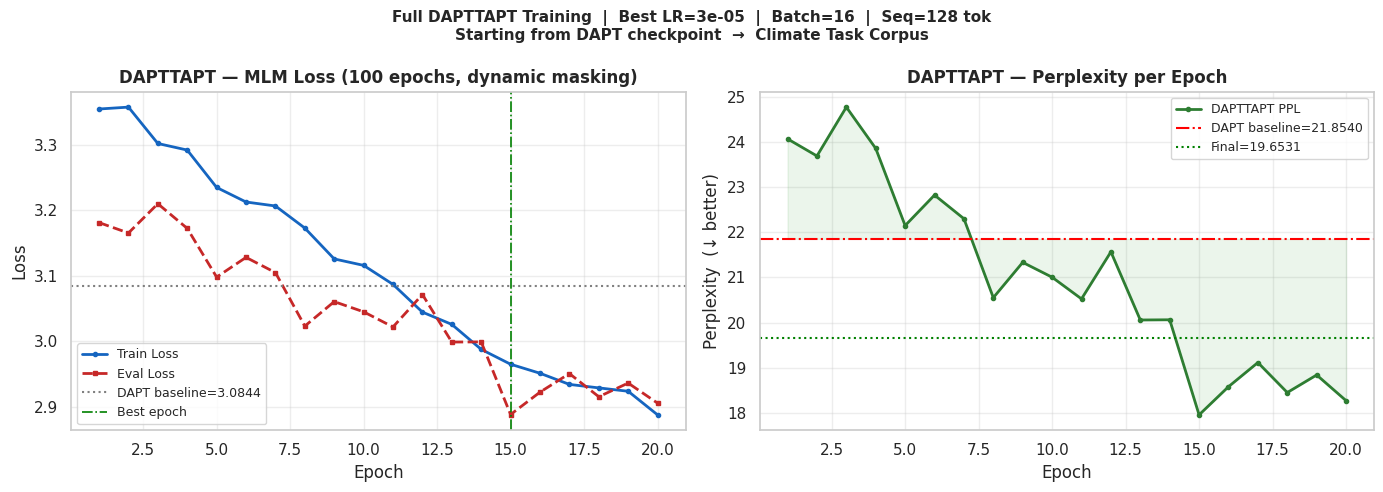

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapttapt/dapttapt_training_curve.png


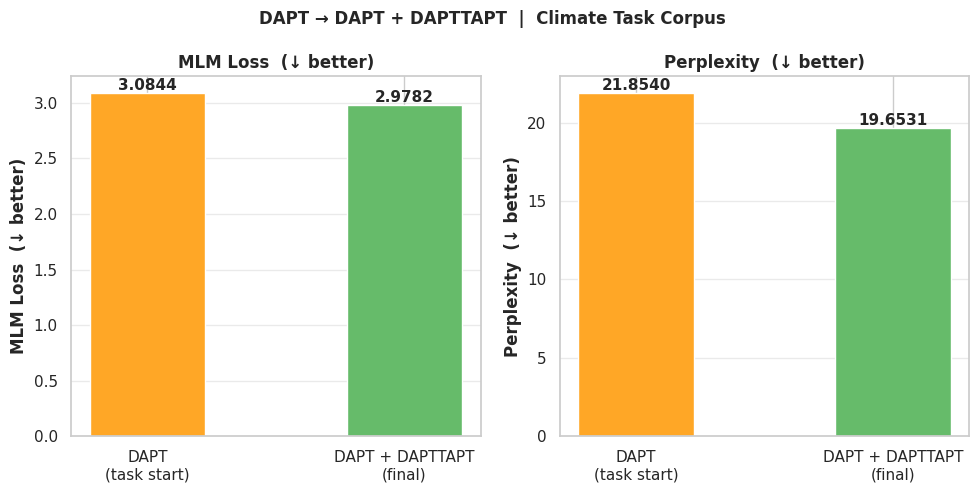

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapttapt/dapttapt_2stage_comparison.png


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

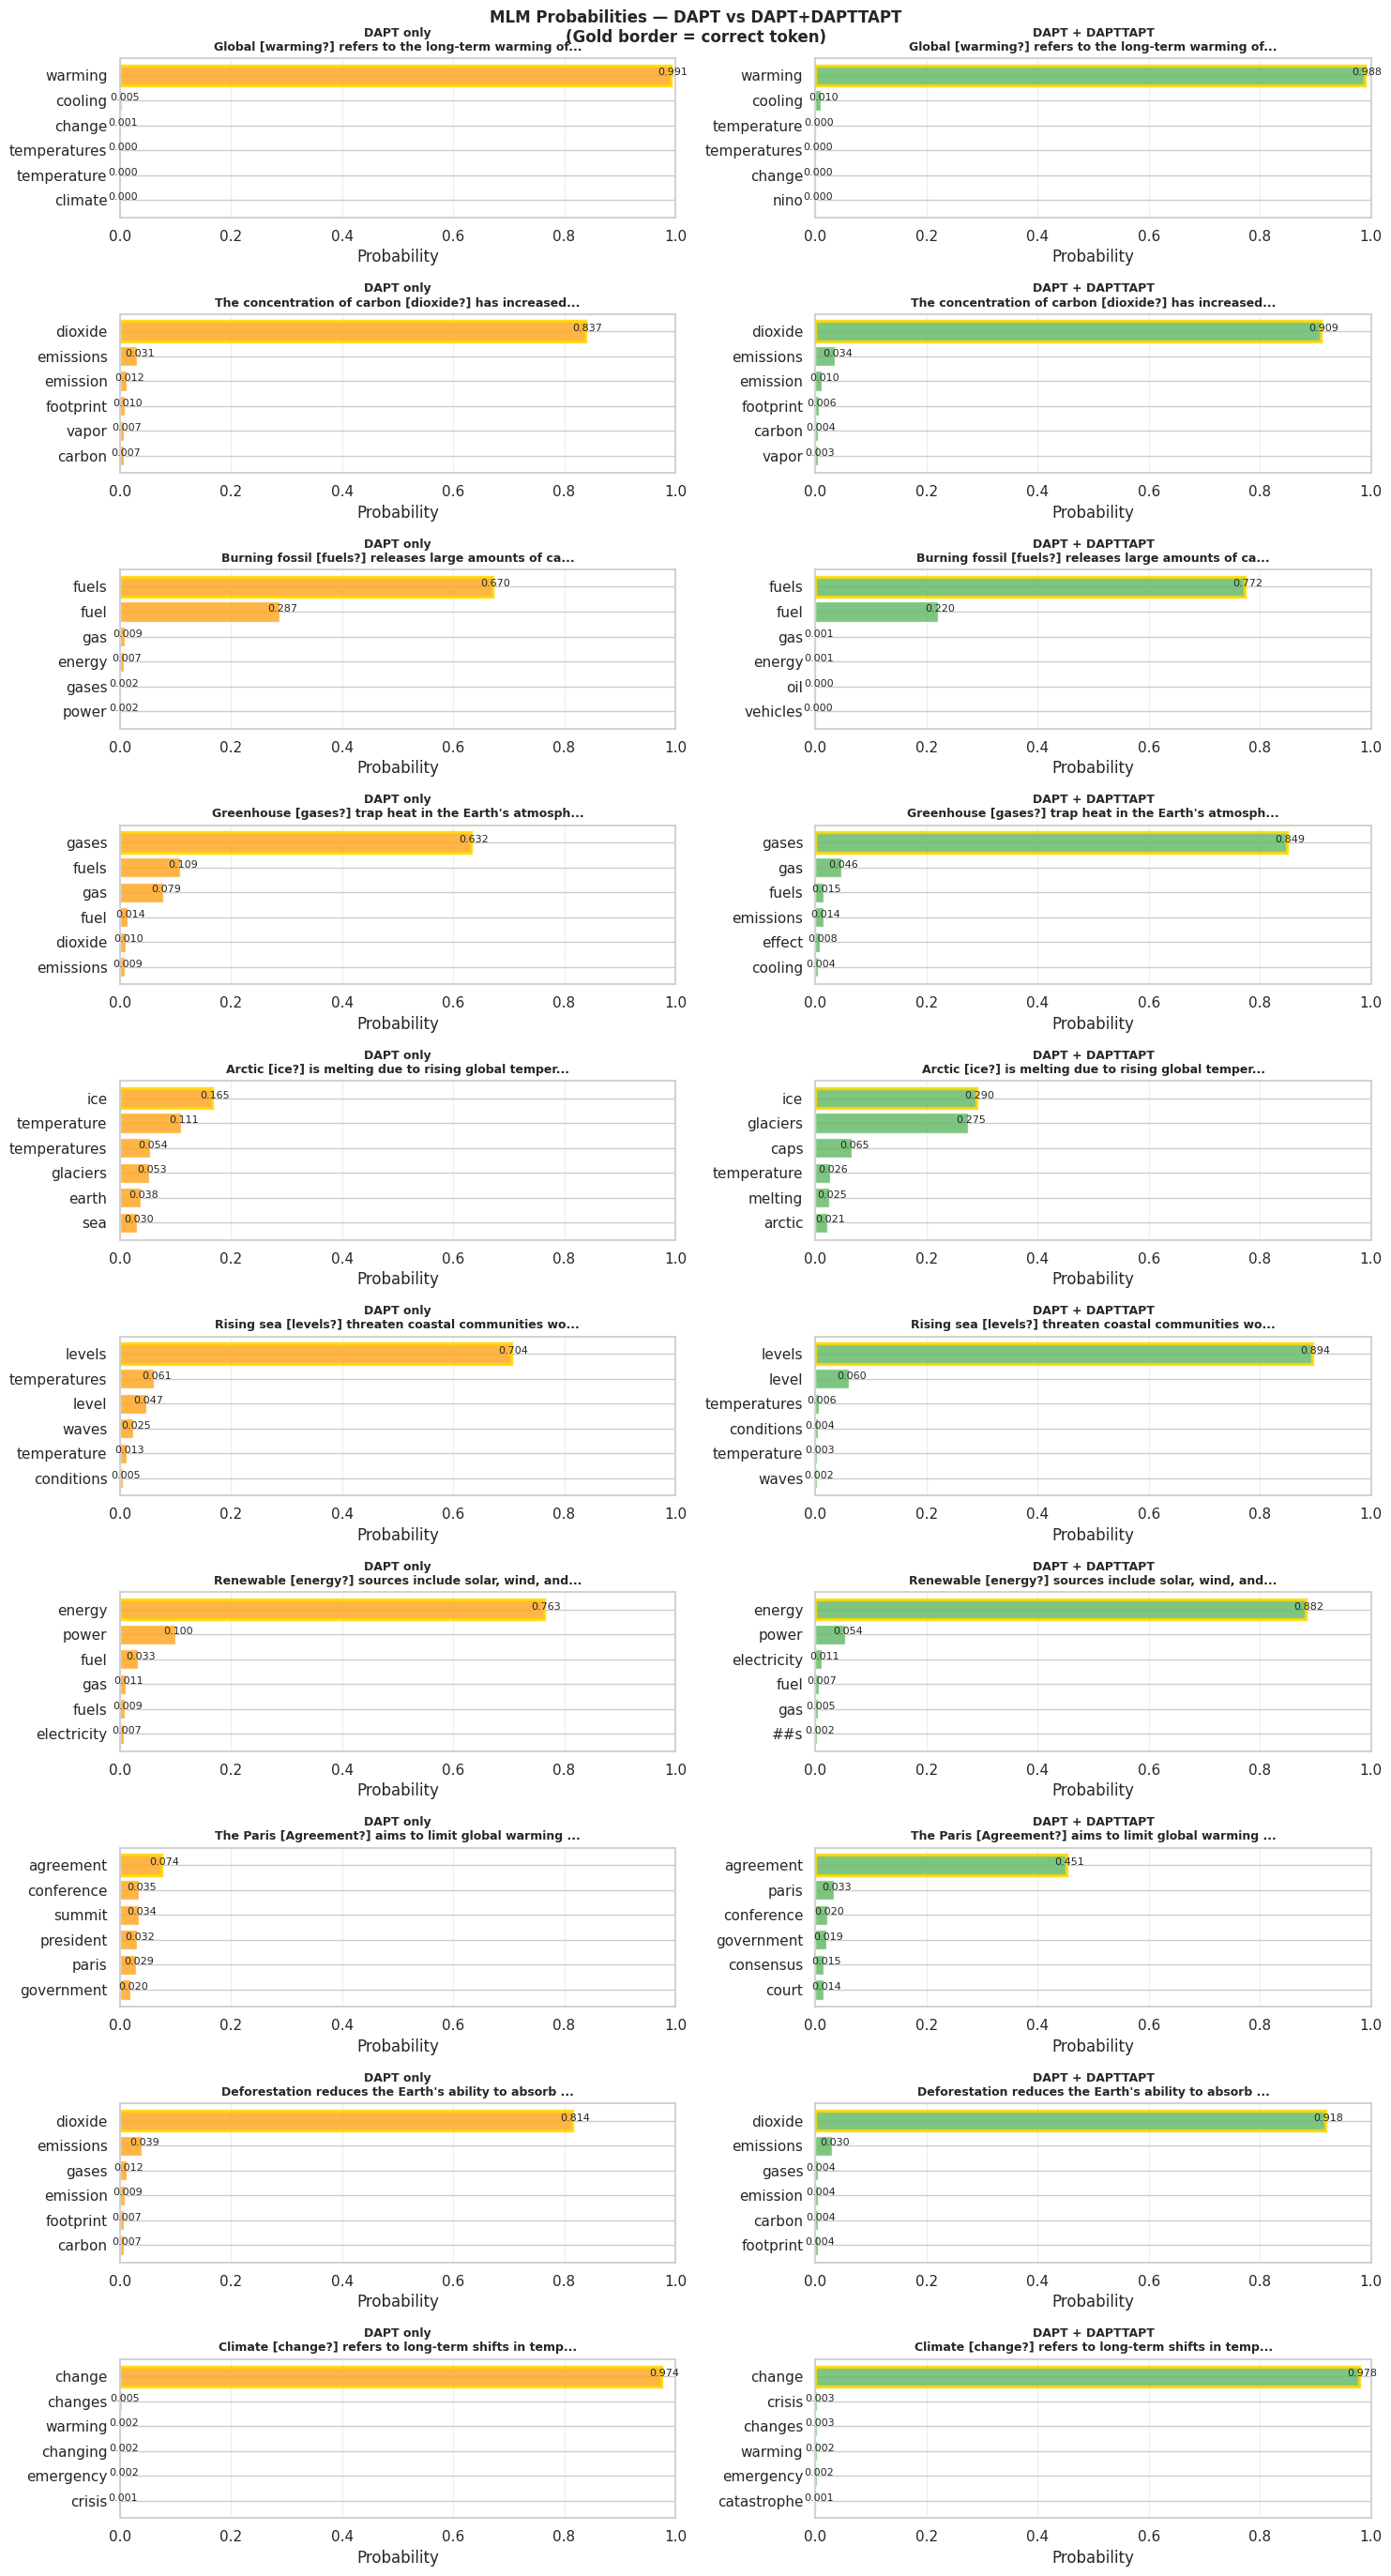

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapttapt/dapttapt_mlm_probabilities.png

Probe                                              DAPT  DAPTTAPT     Delta
---------------------------------------------------------------------------
⚠️   Global [warming] refers to the long-term wa    0.9909    0.9879   -0.0030
✅  The concentration of carbon [dioxide] has i    0.8371    0.9091   +0.0720
✅  Burning fossil [fuels] releases large amoun    0.6702    0.7723   +0.1020
✅  Greenhouse [gases] trap heat in the Earth's    0.6318    0.8487   +0.2169
✅  Arctic [ice] is melting due to rising globa    0.1654    0.2901   +0.1247
✅  Rising sea [levels] threaten coastal commun    0.7039    0.8940   +0.1901
✅  Renewable [energy] sources include solar, w    0.7629    0.8820   +0.1190
✅  The Paris [Agreement] aims to limit global     0.0744    0.4513   +0.3769
✅  Deforestation reduces the Earth's ability t    0.8141    0.9175   +0.1034
✅  Climate [change] refers to long-term shifts    0.9743

In [18]:
sns.set_theme(style='whitegrid', font_scale=1.0)

# ── PLOT A: Full DAPTTAPT training curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(log_df_tapt['epoch'], log_df_tapt['train_loss'], lw=2,
        color='#1565C0', marker='o', ms=3, label='Train Loss')
ax.plot(log_df_tapt['epoch'], log_df_tapt['eval_loss'],  lw=2, ls='--',
        color='#C62828', marker='s', ms=3, label='Eval Loss')
ax.axhline(DAPT_METRICS['loss'], color='gray', ls=':', lw=1.5,
           label=f'DAPT baseline={DAPT_METRICS["loss"]:.4f}')
best_ep = log_df_tapt['eval_loss'].idxmin()
ax.axvline(log_df_tapt['epoch'].iloc[best_ep], color='green',
           ls='-.', lw=1.2, label='Best epoch')
ax.set_title('DAPTTAPT — MLM Loss (100 epochs, dynamic masking)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(alpha=0.35)

ax = axes[1]
ax.plot(log_df_tapt['epoch'], log_df_tapt['perplexity'], lw=2,
        color='#2E7D32', marker='o', ms=3, label='DAPTTAPT PPL')
ax.axhline(DAPT_METRICS['perplexity'], color='red', ls='-.', lw=1.5,
           label=f'DAPT baseline={DAPT_METRICS["perplexity"]:.4f}')
ax.axhline(TAPT_METRICS['perplexity'], color='green', ls=':', lw=1.5,
           label=f'Final={TAPT_METRICS["perplexity"]:.4f}')
ax.fill_between(log_df_tapt['epoch'], log_df_tapt['perplexity'],
                DAPT_METRICS['perplexity'], alpha=0.08, color='green')
ax.set_title('DAPTTAPT — Perplexity per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity  (↓ better)')
ax.legend(fontsize=9); ax.grid(alpha=0.35)

plt.suptitle(
    f'Full DAPTTAPT Training  |  Best LR={BEST_LR:.0e}  |  '
    f'Batch={CFG["full_batch"]}  |  Seq={CFG["seq_len"]} tok\n'
    f'Starting from DAPT checkpoint  →  Climate Task Corpus',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapttapt_training_curve.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# ── PLOT B: 2-stage comparison bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

stages       = ['DAPT\n(task start)', 'DAPT + DAPTTAPT\n(final)']
loss_vals    = [DAPT_METRICS['loss'],       TAPT_METRICS['loss']]
ppl_vals     = [DAPT_METRICS['perplexity'], TAPT_METRICS['perplexity']]
stage_colors = ['#FFA726', '#66BB6A']

for ax, vals, ylabel in [
    (axes[0], loss_vals, 'MLM Loss  (↓ better)'),
    (axes[1], ppl_vals,  'Perplexity  (↓ better)'),
]:
    bars = ax.bar(stages, vals, color=stage_colors, edgecolor='white', width=0.45)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(ylabel, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('DAPT → DAPT + DAPTTAPT  |  Climate Task Corpus',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapttapt_2stage_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# ── PLOT C: MLM fill-mask probes DAPT vs DAPTTAPT ────────────────────────────────
from transformers import pipeline as hf_pipeline

MASK        = tokenizer.mask_token
fill_dapt   = hf_pipeline('fill-mask', model=PATHS['dapt_model'],
                           device=0 if torch.cuda.is_available() else -1)
fill_tapt   = hf_pipeline('fill-mask', model=PATHS['model_dir'],
                           device=0 if torch.cuda.is_available() else -1)

# Task-specific probes — climate domain, narrow vocabulary
PROBES = [
    (f"Global {MASK} refers to the long-term warming of the planet.",             'warming'),
    (f"The concentration of carbon {MASK} has increased rapidly.",                'dioxide'),
    (f"Burning fossil {MASK} releases large amounts of carbon dioxide.",          'fuels'),
    (f"Greenhouse {MASK} trap heat in the Earth's atmosphere.",                   'gases'),
    (f"Arctic {MASK} is melting due to rising global temperatures.",              'ice'),
    (f"Rising sea {MASK} threaten coastal communities worldwide.",                'levels'),
    (f"Renewable {MASK} sources include solar, wind, and hydro power.",          'energy'),
    (f"The Paris {MASK} aims to limit global warming to 1.5 degrees Celsius.",   'Agreement'),
    (f"Deforestation reduces the Earth's ability to absorb carbon {MASK}.",      'dioxide'),
    (f"Climate {MASK} refers to long-term shifts in temperatures and weather.",   'change'),
]

def plot_fill_bar(ax, results, title, color, expected):
    toks = [r['token_str'].strip() for r in results]
    scs  = [r['score'] for r in results]
    bars = ax.barh(toks[::-1], scs[::-1], color=color, alpha=0.85, edgecolor='white')
    for bar, sc in zip(bars, scs[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{sc:.3f}', ha='center', fontsize=8)
    for i, t in enumerate(toks[::-1]):
        if t.lower() == expected.lower():
            bars[i].set_edgecolor('gold'); bars[i].set_linewidth(2.5)
    ax.set_xlim(0, 1.0)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Probability'); ax.grid(axis='x', alpha=0.3)

fig, axes = plt.subplots(len(PROBES), 2, figsize=(15, len(PROBES) * 2.8))

for row, (sent, expected) in enumerate(PROBES):
    rd = fill_dapt(sent, top_k=6)
    rt = fill_tapt(sent, top_k=6)
    short = sent.replace(MASK, f'[{expected}?]')[:52] + '...'
    plot_fill_bar(axes[row][0], rd, f'DAPT only\n{short}',      '#FFA726', expected)
    plot_fill_bar(axes[row][1], rt, f'DAPT + DAPTTAPT\n{short}',   '#66BB6A', expected)

plt.suptitle('MLM Probabilities — DAPT vs DAPT+DAPTTAPT\n(Gold border = correct token)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapttapt_mlm_probabilities.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# Numeric summary
print(f'\n{"Probe":<45}  {"DAPT":>8}  {"DAPTTAPT":>8}  {"Delta":>8}')
print('-'*75)
for sent, expected in PROBES:
    rd = fill_dapt(sent, top_k=50); rt = fill_tapt(sent, top_k=50)
    def gp(res, tok):
        for r in res:
            if r['token_str'].strip().lower() == tok.lower(): return r['score']
        return 0.0
    pd_ = gp(rd, expected); pt = gp(rt, expected)
    lbl = sent.replace(MASK, f'[{expected}]')[:43]
    print(f'{"✅" if pt > pd_ else "⚠️ "}  {lbl:43s}  {pd_:8.4f}  {pt:8.4f}  {pt-pd_:+8.4f}')

In [19]:
eval_results = {
    'dapt_baseline' : DAPT_METRICS,
    'after_dapttapt'    : TAPT_METRICS,
    'improvement'   : {
        'loss_pct_change': round(loss_pct, 4),
        'ppl_pct_change' : round(ppl_pct,  4),
    },
    'dapttapt_config'   : {
        'best_lr'           : BEST_LR,
        'batch_size'        : CFG['full_batch'],
        'epochs_configured' : CFG['tapt_epochs'],
        'epochs_actual'     : int(log_df_tapt['epoch'].max()),
        'early_stopped'     : int(log_df_tapt['epoch'].max()) < CFG['tapt_epochs'],
        'seq_len'           : CFG['seq_len'],
        'mlm_probability'   : CFG['mlm_probability'],
        'dynamic_masking'   : True,
        'start_checkpoint'  : 'DAPT model (dapt_minilm_climate)',
    },
    'timestamp' : datetime.now().isoformat(),
}

with open(PATHS['eval_json'], 'w') as f:
    json.dump(eval_results, f, indent=2)

report = f"""
╔═══════════════════════════════════════════════════════════════╗
║        DAPTTAPT FINAL REPORT — Climate Task Corpus               ║
╚═══════════════════════════════════════════════════════════════╝
Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

TRAINING STRATEGY
  Pipeline         : DAPT → DAPTTAPT  (DAPT + DAPTTAPT combination)
  Start Checkpoint : dapt_minilm_climate  (NOT base MiniLM)
  Task             : Masked Language Modeling — dynamic masking
  LR Sweep values  : {TAPT_LR_SWEEP}
  Best LR          : {BEST_LR:.0e}
  Batch size       : {CFG['full_batch']}
  Seq length       : {CFG['seq_len']} tokens
  Epochs target    : {CFG['tapt_epochs']}
  Epochs actual    : {int(log_df_tapt['epoch'].max())}  (early stop patience={CFG['early_stop_patience']})

METRICS
  Stage             Loss          Perplexity
  DAPT baseline  : {DAPT_METRICS['loss']:.6f}     {DAPT_METRICS['perplexity']:.4f}
  DAPT + DAPTTAPT    : {TAPT_METRICS['loss']:.6f}     {TAPT_METRICS['perplexity']:.4f}
  Improvement    : {loss_pct:+.2f}% loss  |  {ppl_pct:+.2f}% perplexity

PLOTS SAVED
  dapttapt_lr_sweep.png           — 3 LR curves during sweep
  dapttapt_training_curve.png     — full 100-epoch loss + PPL
  dapttapt_2stage_comparison.png  — DAPT vs DAPT+DAPTTAPT bar chart
  dapttapt_mlm_probabilities.png  — fill-mask DAPT vs DAPT+DAPTTAPT

VERDICT
  {verdict}
"""

with open(PATHS['report_txt'], 'w') as f:
    f.write(report)
print(report)
print(f'Report   → {PATHS["report_txt"]}')
print(f'Eval JSON → {PATHS["eval_json"]}')


╔═══════════════════════════════════════════════════════════════╗
║        DAPTTAPT FINAL REPORT — Climate Task Corpus               ║
╚═══════════════════════════════════════════════════════════════╝
Generated : 2026-05-26 13:20:50

TRAINING STRATEGY
  Pipeline         : DAPT → DAPTTAPT  (DAPT + DAPTTAPT combination)
  Start Checkpoint : dapt_minilm_climate  (NOT base MiniLM)
  Task             : Masked Language Modeling — dynamic masking
  LR Sweep values  : [5e-06, 1e-05, 3e-05]
  Best LR          : 3e-05
  Batch size       : 16
  Seq length       : 128 tokens
  Epochs target    : 25
  Epochs actual    : 20  (early stop patience=5)

METRICS
  Stage             Loss          Perplexity
  DAPT baseline  : 3.084400     21.8540
  DAPT + DAPTTAPT    : 2.978200     19.6531
  Improvement    : -3.44% loss  |  -10.07% perplexity

PLOTS SAVED
  dapttapt_lr_sweep.png           — 3 LR curves during sweep
  dapttapt_training_curve.png     — full 100-epoch loss + PPL
  dapttapt_2stage_comparison